<a href="https://colab.research.google.com/github/Alvaroort21/Cadenas-de-Markov/blob/main/MC_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar MCs

El objetivo es aprender a simular trayectorias de una MC, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos algunas de las imágenes vistas en las diapositivas, y haremos simulaciones relacionadas con los dos teoremas de convergencia que hemos visto: el teorema de convergencia de MCs y el teorema ergódico.

**Nota:** Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Igual que con el PAS y los GPs, tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

In [5]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Simular la trayectoria de una MC

Vamos a definir una función que nos permita generar trayectorias de una MC dada. Primero la definiremos de la manera más sencilla, usando dos bucles ```for```. Después veremos que se puede eliminar uno de los bucles para hacerlo más eficiente.

**Importante**: para una MC con $m$ estados, nosotros nos hemos referido a ellos como $\{1,2,\dots,m\}$. Y queremos que esta función que simula trayectorias nos devuelva efectivamente esos posibles estados. Hay al menos dos formas de hacer esto:

1. Hacer toda la implementación usando dicha nomenclatura: $\{1,2,\dots,m\}$.

2. Hacer la implementación usando la siguiente nomenclatura: $\{0,1,\dots,m-1\}$. Es decir, al estado $i$-ésimo pasamos a llamarlo "estado $i-1$" durante la implementación. Y, al final de la función, cuando vayamos a devolver los valores, sumamos $+1$ para que el usuario reciba la verdadera nomenclatura.

La opción 1. parece más sencilla desde el punto de vista lógico. Pero, a la hora de hacer la implementación, puesto que Numpy empieza la indexación en 0 (es decir, el primer elemento de un array de numpy está en la posición 0), el código queda mucho más sencillo y limpio si usamos la opción 2.

Cada uno puede elegir la opción que quiera (siempre que esté "bien hecho"). Se recomienda usar la 2 por mayor sencillez.

In [6]:
# Con dos bucles for

def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  # Paso 0: por comodidad, podemos crear una variable que guarde el valor de m (el número de estados)
  m = np.arange(P.shape[0])  #P.shape[0] es el número de filas de P (m). m=[0,1,...m-1]

  # Paso 1: crear un array de shape (n_samples, n_steps) con valores arbitrarios. Este array será el que devolvamos, una vez relleno.
  trayectorias = np.zeros((n_samples, n_steps),dtype=int)   #matriz de ceros

  # Paso 2: simula el estado inicial para cada una de las n_samples trayectorias y guárdalo en la primera columna del array trayectorias.
  # Mira la función np.random.choice, que permite simular justo lo que buscamos a través de sus variados argumentos.
  trayectorias[:,0] = np.random.choice(m, size=n_samples, p=pi_sup_1) #Números aleatorios del 0 a m-1 con probabilidades pi^1

  # Paso 3: iterando sobre n_samples y n_steps, rellena todo el array "trayectorias". Puedes usar de nuevo np.random.choice
  for step in range(1, n_steps):
    for sample in range(n_samples):
      trayectorias[sample, step] = np.random.choice(m, p=P[trayectorias[sample,step-1],:] )

  return trayectorias+1

A continuación vamos a hacer una versión más eficiente de esta función, eliminando uno de los bucles ```for``` (concretamente, el que recorre ```n_samples```). El otro bucle, el que recorre ```n_steps```, no se puede eliminar porque la construcción de la cadena es un proceso inherentemente iterativo. Pero la dimensión sobre ```n_samples``` sí que es conceptualmente paralelizable.

In [7]:
#Creamos una función que permita hacer lo mismo que ramdom.choice pero pudiendo introducir como parámetro de probabilidad una matriz y así generar distintos números aleatorios con probabilidad cada fila de la matriz
def random_choice_matrix(n_samples,estados_anteriores, P):
  P_acum = np.cumsum(P, axis=1) # suma acumulada de P ,axis=1 para que sea por filas.
  aux = np.random.rand(n_samples,1)  #Genera n_samples numeros aleatorios entre 0 y 1
  return np.sum(P_acum[estados_anteriores] < aux, axis=1)
#Al generar números en una U(0,1), la probabilidad de que un número este en un intervalo es la longitud del intervalo.
#Así, al hacer la suma acumulada de P por filas, basta mirar entre que dos columnas de la fila está el número generado para que la probabilidad coincida con la deseada.
#Basta hacer la suma por filas con la condición lógica P_acum[estados_anteriores,:] < aux para obtener el estado que resulta.

In [8]:
# Solo un for

def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.

  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  # Paso 0: por comodidad, podemos crear una variable que guarde el valor de m (el número de estados)
  m = np.arange(P.shape[0])  #P.shape[0] es el número de filas de P (m). m=[0,1,...m-1]


  # Paso 1: crear un array de shape (n_samples, n_steps) con valores arbitrarios. Este array será el que devolvamos, una vez relleno.
  trayectorias = np.zeros((n_samples, n_steps),dtype=int)   #matriz de ceros

  # Paso 2: simula el estado inicial para cada una de las n_samples trayectorias y guárdalo en la primera columna del array trayectorias.
  # Mira la función np.random.choice, que permite hacer justo esto a través de sus variados argumentos.
  trayectorias[:,0] = np.random.choice(m, size=n_samples, p=pi_sup_1) #Números aleatorios del 0 a m-1 con probabilidades pi^1

  # Paso 3: iterando sobre n_steps, utiliza numpy (en vez de for) para generar conjuntamente todas las trayectorias.
  for step in range(1, n_steps):
    trayectorias[:, step] =  random_choice_matrix(n_samples,trayectorias[:,step-1],P)

  return trayectorias+1

Una vez implementadas ambas opciones, utiliza las siguientes celdas para evaluar su eficiencia.

El comando ```%%timeit``` al principio de una celda hace que se ejecute varias veces y se devuelva un resumen de tiempo de ejecución (media y desviación típica sobre diferentes pruebas).



In [9]:
%%timeit
# Celda para la versión menos eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

1.43 s ± 567 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
%%timeit
# Celda para la versión más eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

4.92 ms ± 211 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Vemos que la versión con un solo bucle for es más rápida que la otra.

Por último en esta sección, utiliza alguna de las funciones anteriores para generar seis trayectorias durante 50 pasos, y haz una visualización similar a la diapositiva 24.

Puedes utilizar la función ```plt.step```.

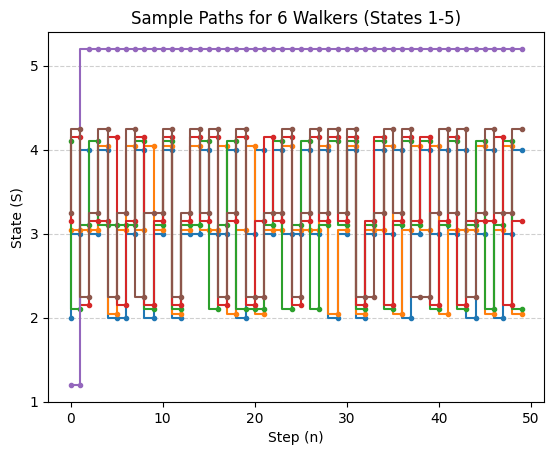

In [52]:
# Dibujamos trayectorias de 50 pasos cada una para 5 estados
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 6
n_steps = 50
ep=0.05
trayectorias = simular_trayectorias_effic(P, pi_1, n_samples, n_steps) # Trayectorias
desplazamiento = np.arange(n_samples) * ep  #desplazamos para que no se solape
plt.step(np.arange(n_steps), trayectorias.T + desplazamiento, marker='.') #a diferencia de plt.plot(), esta versión requiere pasarle como parámetro el eje x
plt.title('Sample Paths for 6 Walkers (States 1-5)')
plt.xlabel('Step (n)')
plt.ylabel('State (S)')
plt.yticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## 2. Distribución marginal de una MC

Vamos a definir una función que nos permita obtener la distribución marginal de una MC en un instante dado.

In [12]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Función para calcular la distribución marginal de una MC en cierto instante.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n: instante de tiempo en el que se quiere calcular la distribución marginal. Int.

  Output:
  marginal: distribución marginal en el instante n (es decir, lo que hemos llamado pi^{(n)}). Numpy array con shape (m,).
  """

  marginal = pi_sup_1 @ np.linalg.matrix_power(P,n-1)  #np.linalg.matrix_power sirve para elevar matrices; @ multiplica matrices.
  return marginal

Utiliza la función anterior para visualizar empíricamente que la distribución marginal de nuestra MC converge a diferentes distribuciones si empezamos en distribuciones iniciales diferentes. Es decir, reproduce las imágenes de las diapositivas 61 y 63.

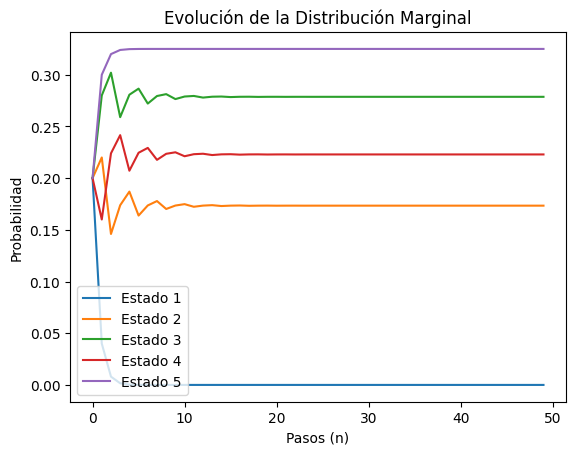

In [53]:
# Evolución de la distribución marginal

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

marginales = np.zeros((5,50))  #matriz de 0 de 5 filas y 50 columnas
for i in range(50):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i+1) #llenamos la matriz la fila n con la marginal en el paso n
plt.plot(marginales.T)  #Pintamos todas
plt.title('Evolución de la Distribución Marginal')
plt.xlabel('Pasos (n)')
plt.ylabel('Probabilidad')
plt.legend(['Estado 1', 'Estado 2', 'Estado 3', 'Estado 4', 'Estado 5'])
plt.show()


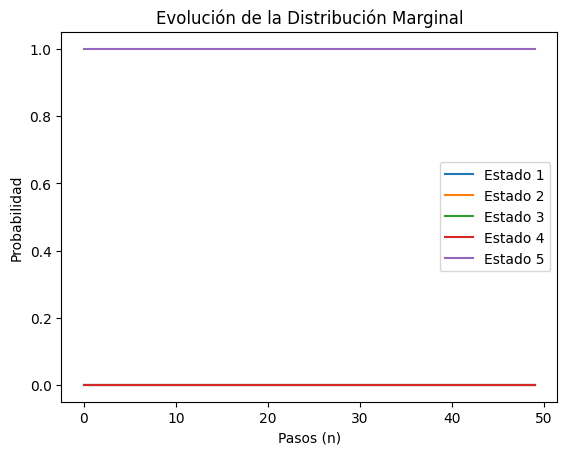

In [54]:
# Cambiamos la pi^1 por otra
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0 ,0, 0, 0, 1])
marginales = np.zeros((5,50))  #matriz de 0 de 5 filas y 50 columnas
for i in range(50):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i+1) #llenamos la matriz la fila n con la marginal en el paso n
plt.plot(marginales.T)  #Pintamos todas
plt.title('Evolución de la Distribución Marginal')
plt.xlabel('Pasos (n)')
plt.ylabel('Probabilidad')
plt.legend(['Estado 1', 'Estado 2', 'Estado 3', 'Estado 4', 'Estado 5'])
plt.show()



## 3. Diagrama de transición de estados

Vamos a definir una función para dibujar el diagrama de transición de estados de una MC. Como hemos visto, esta es una de las formas más habituales de visualizar una MC.

Trata de entender la siguiente función (al menos sus argumentos de entrada y su funcionamiento general, hay detalles sobre los "edge_labels" que son menos relevantes para nosotros).

In [55]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  # Use DiGraph (Directed Graph)
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  # Define layout
  pos = nx.circular_layout(G)

  # Create the plot
  plt.figure(figsize=(8, 6))

  # Draw nodes and edges
  # 'connectionstyle' curves the edges to prevent overlap on bidirectional paths
  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  # 2. Add the weights as labels
  edge_labels = nx.get_edge_attributes(G, 'weight')

  # Optional: Format labels to look cleaner (e.g., 0.5 instead of 0.500000)
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("State Transition Diagram with Weights")
  plt.show()

Usa la función anterior para dibujar el diagrama de transición de estados de nuestra MC. Esta es una figura que hemos visto repetidamente (la primera vez en la diapositiva 27).

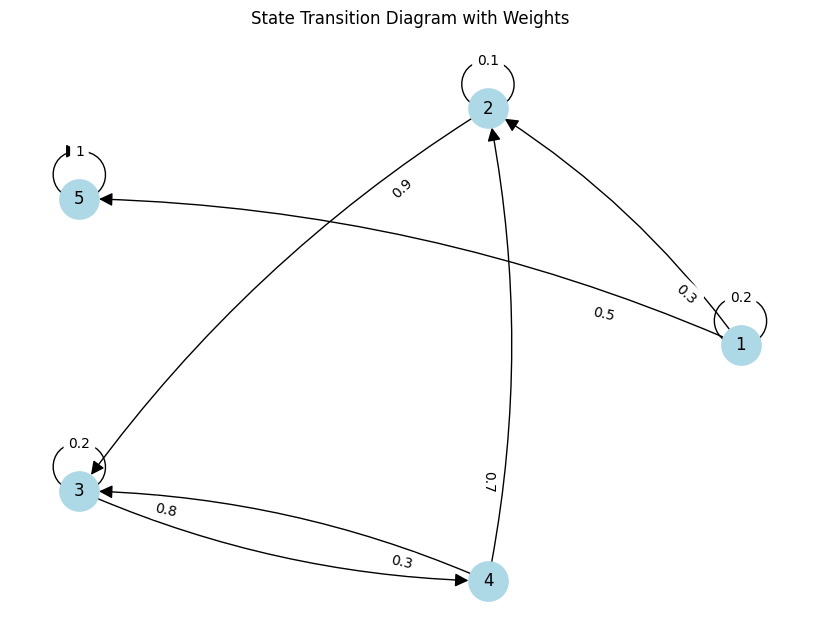

In [16]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
dibujar_diagrama_transicion(P, [1,2,3,4,5])

## 4. Teorema de convergencia de MCs

En esta sección vamos a ilustrar tres ideas que hemos estudiado en el contexto del teorema de convergencia de MCs:

1. Una MC es unicadenal y aperiódica $\iff$ la distribución marginal converge siempre a la misma distribución (independientemente de la distribución inicial).
2. Una MC es aperiódica $\iff$ la distribución marginal converge siempre (aunque el límite puede depender de la distribución inicial).
3. Para MCs en las hipótesis del teorema de convergencia de MCs, la distribución empírica de proporciones del estado $i$-ésimo, lo que habíamos llamado $p_i(n_{samples}, n_{steps})$, converge a la componente $i$-ésima de la distribución estacionaria cuando incrementamos $n_{samples}, n_{steps}$.


Vamos a empezar por definir una función que nos permita visualizar la evolución de la distribución marginal de una MC. Este tipo de gráfica ya la habíamos obtenido en la sección 3, cuando se reprodujeron las diapositivas 61 y 63. No obstante, aquí se encapsula en una función y se hace de manera más eficiente que allí:

In [17]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
  """
  Función para visualizar la evolución de la distribución marginal para una MC.

  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_steps: instante de tiempo hasta el que se quiere visualizar. Int.

  Output:
  La función no devuelve nada por "return", simplemente realiza un gráfico.
  """

  # Paso 1: crear un array con shape (m, n_steps) y rellenarlo con las marginales en cada paso.

  # A diferencia de lo que se proponía en la sección 3, no uses la función "obtener_marginal" que habíamos definido. Simplemente ve obteniendo las marginales una a una a partir de la anterior multiplicando por P.
  marginales = np.zeros((P.shape[0], n_steps))  #matriz de ceros de shape (m,n_steps)
  marginales[:,0] = pi_sup_1 #En la primera columna el pi^1
  for i in range(1,n_steps):
    marginales[:,i]=marginales[:,i-1] @ P  # pi^n = pi^(n-1) * P

  # Paso 2: Dibujar la trayectoria de cada componente de la marginal. Esto puede ser análogo a lo que se hizo al reproducir las diapositivas 61 y 63.
  plt.plot(marginales.T)  #Pintamos todas
  plt.title('Evolución de la Distribución Marginal')
  plt.xlabel('Pasos (n)')
  plt.ylabel('Probabilidad')
  leyendas = [f'Estado {i+1}' for i in range(P.shape[0])]  #Creamos la leyenda en función del número de estados m
  plt.legend(leyendas)
  plt.show()

Considera la siguiente matriz de transición:

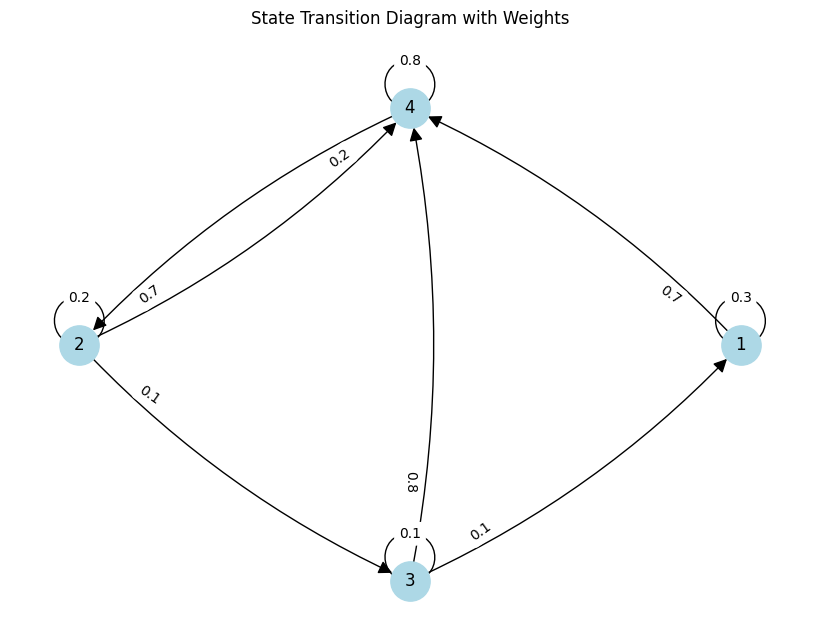

In [18]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Una MC con esta matriz de transición es unicadenal ya que hay una única clase de comunicación cerrada y es aperiódica ya que todos los estados tienen lazos. Por tanto, está en las condiciones del teorema de convergencia de MCs. Por tanto, la marginal debe converger a una única distribución estacionaria independientemente de la distribución inicial.

En la siguiente celda se obtiene una distribución inicial aleatoria para la MC, y se representan los primeros $50$ pasos de la marginal (también se imprime por pantalla la marginal en el paso 50). Completa la celda y luego ejecútala varias veces para comprobar que siempre se converge al mismo límite.

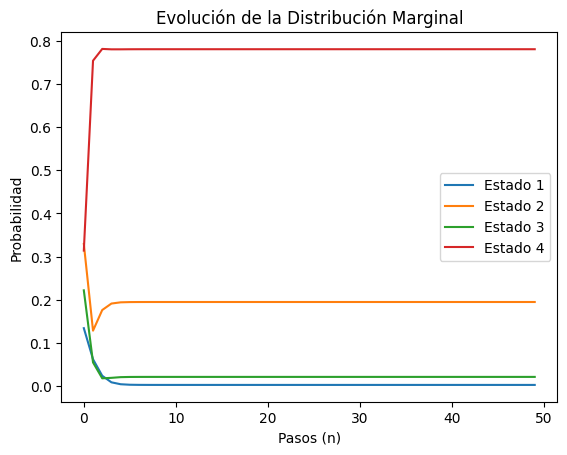

[0.00309598 0.19504644 0.02167183 0.78018576]


In [57]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
#Generamos un pi super 1 aleatorio mediante una U(0,1)
uniforme = np.random.rand(P.shape[0]) #generamos m números aleatorios de una uniforme.
pi_sup_1 = uniforme/np.sum(uniforme) #normalizamos.

visualizar_evolucion_marginal(P, pi_sup_1, 50)
print( obtener_marginal(P, pi_sup_1, 50) )

Vemos que siempre converge al mismo limite

Cuando hicimos un esbozo de demostración del teorema de convergencia de MCs, recordar diapositivas 89 y 90, vimos que la sucesión de matrices $\{P^n\}_n$ convergía a una matriz en la que todas las filas eran iguales (y coincidían con la única distribución estacionaria).

Vamos a visualizar varios términos de esta sucesión para comprobar empíricamente que esto sucede. Primero vamos a ver cómo podemos representar visualmente una matriz. Una manera habitual es mediante un "heatmap" (mapa de calor). A continuación se realiza dicho gráfico para la MC anterior (mira el gráfico y entiéndelom en particular el código de color):

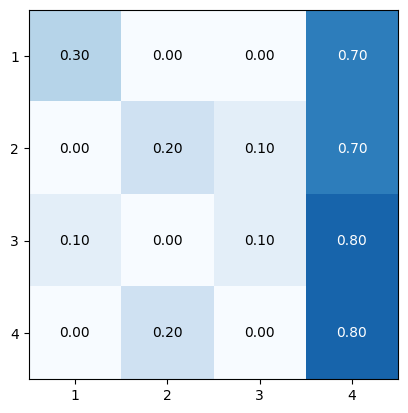

In [20]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Dibujar el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadir texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))

plt.show()

Completa la siguiente celda para ver la evolución de $\{P^n\}_n$ en tres instantes: $n=1,2,10$. Comprueba que, efectivamente, esta sucesión parece estabilizarse en una matriz en las que todas las filas son la misma. Y que además coincide con la distribución estacionaria que obtuvimos empíricamente dos celdas más arriba, cuando vimos dónde parecía estabilizarse la marginal de la MC en el paso $50$. (Recuerda que parecía estabilizarse en [0.00309598 0.19504644 0.02167183 0.78018576]).

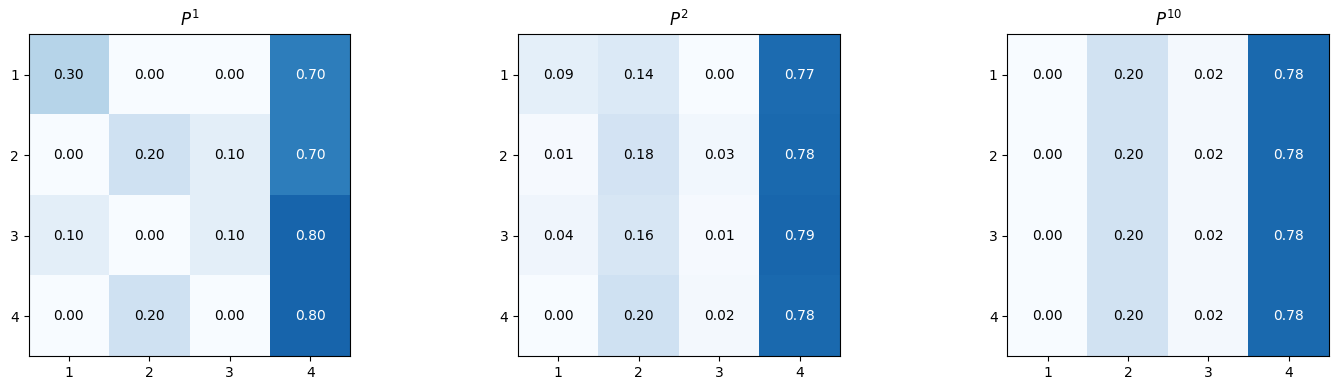

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    Pn =  np.linalg.matrix_power(P,n)  #Eleva P a 1,2,10.

    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

Vemos que en la última matriz, las filas son iguales y coinciden con el límite anteriormente comprobado.

Vamos ahora a mirar el segundo punto de esta sección. Vamos a mirar una MC que sea periódica y el periodo de cada estado.

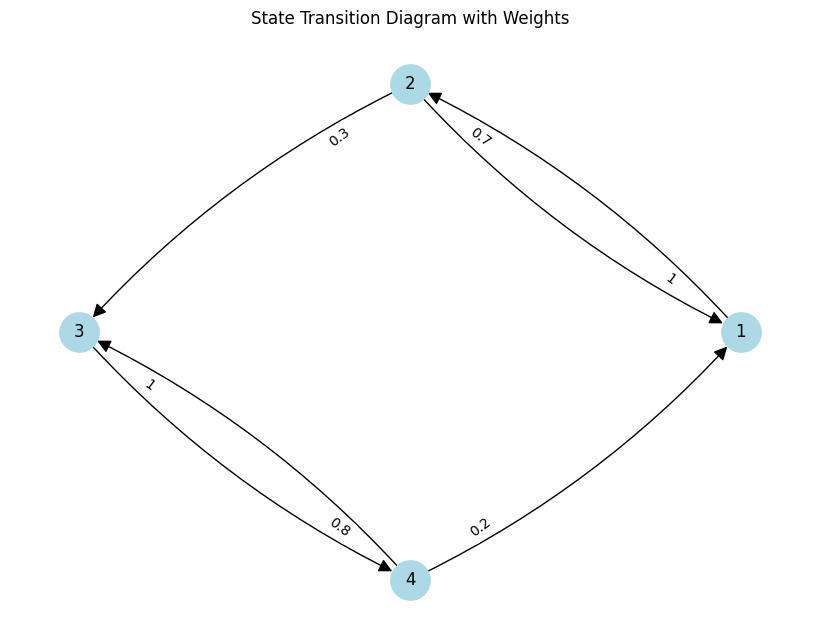

In [56]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

Los periodos de los 4 estados son los siguientes:


1.   d(1) = mcd{2,4,6,...} = 2
2.   d(2) = mcd{2,4,6,...} = 2
3.   d(3) = mcd{2,4,6,...} = 2
4.   d(4) = mcd{2,4,6,...} = 2

En nuestro ejemplo, solo hay una clase de comunicación y es cerrdada, por lo que todos los estados son recurrentes. Al tener todos periodo 2, concuímos que la cadena es periódica

En las siguientes tres celdas se usa la función "visualizar_evolucion_marginal" para ver la evolución de la marginal para tres distribuciones iniciales diferentes. En cada celda, también se imprime por pantalla la marginal en el paso $50$:

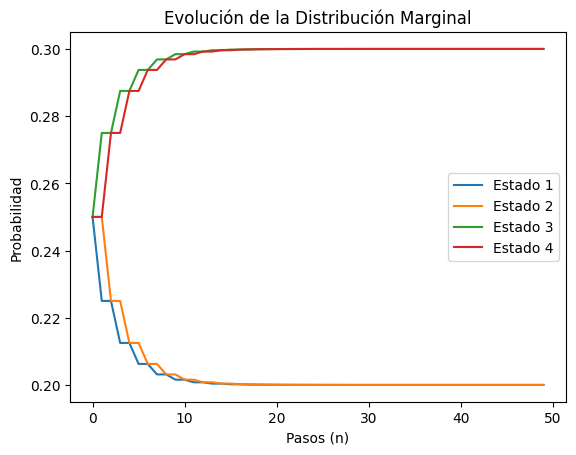

[0.2 0.2 0.3 0.3]


In [23]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

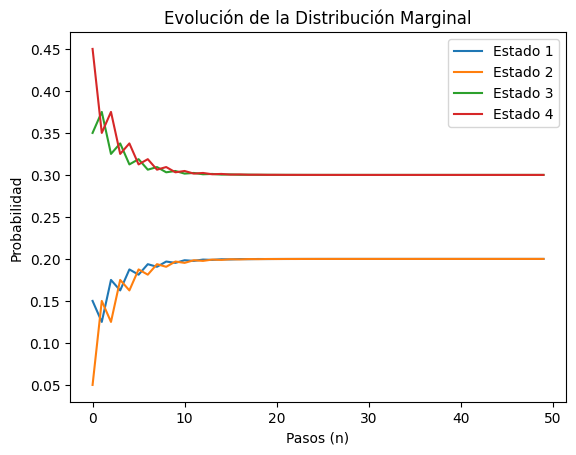

[0.2 0.2 0.3 0.3]


In [24]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

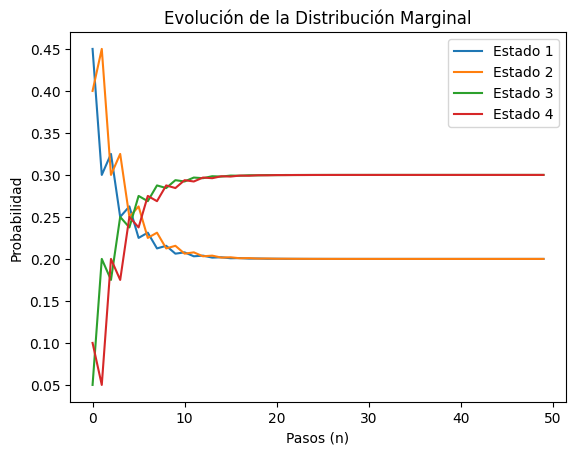

[0.20000001 0.20000001 0.29999999 0.29999999]


In [25]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

Observa que, en los tres casos, parece producirse convergencia de la marginal a la distribución [0.2 0.2 0.3 0.3]. Efectivamente, se puede demostrar que la MC converge para esas tres condiciones iniciales. ¿Contradice esto el resultado enunciado en la diapositiva 96?
La repuesta es no ya que hemos visto que la cadena es periódica, por lo que existen condiciones iniciales para los que la marginal de la MC no converge.

Para mostrar que no lo contradice, propón en la siguiente celda una distribución inicial para la que no haya convergencia (y visualízalo):

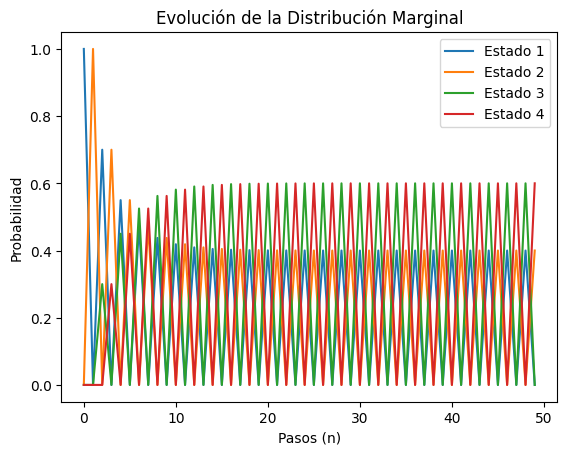

[0.         0.40000004 0.         0.59999996]


In [26]:
pi_sup_1 = np.array([1, 0, 0, 0]) #empezamos siempre en el estado 1
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

Vemos que no hay covergencia.

Vamos a mirar el tercer y último punto de esta sección. En la siguiente celda, vamos a definir una función que calcula las proporciones $p_i(n_{samples}, n_{steps})$ para una trayectoria aleatoria de una MC dada.

De hecho, dada la MC y dados los valores de $n_{samples}$ y $n_{steps}$, la siguiente función devuelve todas las proporciones $p_i(n_{samples}, n)$ con $i=1,\dots,m$ y $n=1,\dots,n_{steps}$.



In [34]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):
  """
  Función que obtiene las proporciones empíricas de cada uno de los estados y en cada uno de los pasos, cuando simulamos una cantidad dada de trayectorias.

  Input:

  n_samples: número de trayectorias a simular. Int.
  n_steps: paso hasta el que se quieren calcular las proporciones. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:

  props: Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps. Array de shape (m, n_steps).
  """

  # Paso 1: utilizar la función "simular_trayectorias_effic" para simular n_samples trayectorias durante n_steps pasos.
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps) # (n_samples, n_steps)

  # Paso 2: compara cada item del array anterior con cada uno de los estados i=1,...,m.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_samples, n_steps) que en cada posición (i,j,k) contenga True/False según si el ítem (j,k) del array "trayectorias" es igual a "i" (True) o no lo es (False).
  m=P.shape[0] #número de estados
  estados = np.arange(m).reshape(m, 1, 1)+1  #np.arange(m) crea un array de una dimensión desde 0 a m-1. Al hacerle el reshape, el array se transforma a otro con shape (3,1,1). Luego se le suma uno para que los estados empiecen en 1.
  is_equal_bool = (trayectorias == estados)   # Al comparar (m, 1, 1) con (n_samples, n_steps), se devuelve con broadcasting un array booleano de shape (m, n_samples, n_steps)

  # Paso 3: fíjate que las proporciones a devolver (props) no son más que hacer la media en la dimensión de "n_samples" en el array anterior (suponiendo que cada True cuenta como +1 y cada False cuenta como +0).
  # Utiliza np.mean() y su argumento "axis=..." para obtener el "props" buscado.
  props = np.mean(is_equal_bool, axis=1)  # (m,n_steps)

  return props

Utiliza la función anterior para visualizar la evolución de $p_i(k,k)$ para cada uno de los $i=1,\dots,m$ cuando $k$ crece. Vamos a hacer la visualización para la MC aperiódica y unicadenal que usamos al principio de esta sección. Para ello, rellena la siguiente celda:

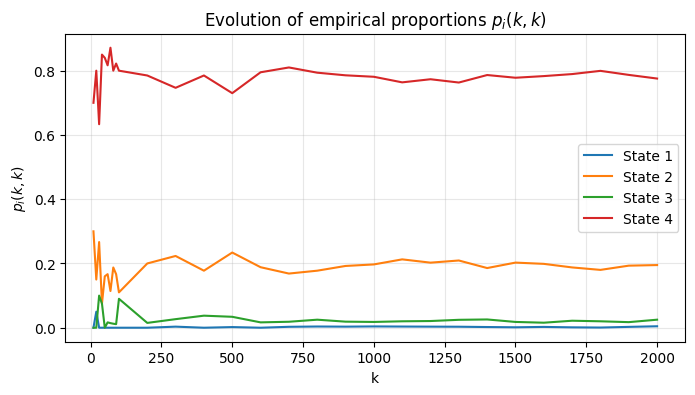

[0.0045 0.195  0.025  0.7755]
[0.00309598 0.19504644 0.02167183 0.78018576]


In [36]:
# Definimos la MC
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0]

# Definimos el "grid" de valores k que vamos a recorrer: 10, 20, 30, ... 100, 200, 300, ..., 2000
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
# Guardamos los resultados en un array "props_plot" de shape (m, len(grid)). (Nótese que len(grid) no es más que la longitud del grid).
props_plot = np.zeros((m, len(grid)))   # (m, len(grid))
for j,k in enumerate(grid):  #j en length(grid), k in grid
  props_plot[:,j] = proporciones_empiricas_hasta_cierto_paso(k, k, P, pi_sup_1)[:,-1]  #-1 para quedarnos con la última columna

# A continuación se hace el gráfico. (nada que completar aquí)
plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(grid, props_plot[i,:], label=f"State {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolution of empirical proportions $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla dos cosas:
# Primero, las proporciones para el último valor de k, es decir, p_i(2000,2000).
# Segundo, la distribución estacionaria de la MC.
# Según vimos en clase, lo primero debería parecerse a lo segundo para k grande. Y efectivamente vemos que es así.
# No obstante, dependiendo de la ejecución concreta, se parecerá más o menos (una cuestión interesante sería estudiar la velocidad de convergencia, que no parece ser muy elevada porque, para k=2000, aún no parece estabilizarse del todo)
print(props_plot[:,-1])
print(obtener_marginal(P, pi_sup_1, 50) )

## 5. Teorema ergódico

En esta sección vamos a verificar empíricamente el teorema ergódico para algunas MCs.

Recuerda que el teorema ergódico se enunciaba para una función $f:S\to\mathbb{R}$ arbitraria. Aquí vamos a considerar la función indicadora $f_i$ que se comentó en la diapositiva 107. Por tanto, estaremos calculando lo que denotábamos por $q_i(n)$ en la diapositiva 106. Recuerda que $q_i(n)$ no es más que la frecuencia (o proporción) de visita al estado $i$-ésimo para una trayectoria aleatoria de la MC, es decir:


$$q_i(n) = \frac{\textrm{Cantidad de veces que se visita $i$ en los $n$ primeros pasos}}{n}$$

Como sabemos, se debe cumplir $q_i(n)\geq 0$ y $\sum_i q_i(n) = 1$.  


Vamos a empezar por definir una función que, dada una MC (```P``` y ```pi_sup_1```) y una cantidad de pasos ```n_steps```, calcule las cantidades $q_i(n)$ para cada $i=1,\dots,m$ y cada $n=1,\dots,n_{steps}$. Estos valores los devolverá en un array con shape (m, n_steps).

In [39]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
  """
  Función que calcula la frecuencia empírica de visitas a cada uno de los estados para una trayectoria de una MC hasta cierto paso.

  Input:
  n_steps: paso hasta el que queremos calcular las frecuencias. Se calcularán las frecuencias para n pasos, con n=1,2,..., n_steps. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).

  Output:
  frecuencias_hasta_cierto_paso: frecuencias empíricas obtenidas, es decir el valor q_i(n) para i=1,...,m y n=1,...,n_steps. Array con shape (m, n_steps)
  """

  # Paso 1: simular 1 trayectoria para la MC, hasta el paso n_steps
  trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps)

  # Paso 2: compara cada valor obtenido con cada uno de los m posibles estados.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_steps) que en la posición (i,j) contenga True/False: True si en el paso j la trayectoria ha visitado justo el estado i, y False en otro caso.
  m = P.shape[0] #estados.
  estados = np.arange(m).reshape(m, 1) + 1 #de forma similar a la función de proporciones empíricas, crea un array de shape (m,1)
  is_equal_bool = (trayectoria == estados)  # Al comparar (m, 1) con (1, n_steps), se devuelve con broadcasting un array booleano de shape (m, n_steps)

  # Paso 3: A partir del array "is_equal_bool", piensa cómo obtener un array "recuentos_hasta_cierto_paso" que tenga la misma shape (m, n_steps), y que en el elemento (i,j) contenga
  # la cantidad de veces que se ha visitado el estado i-ésimo hasta el paso j-ésimo. Puedes mirar la función np.cumsum y tener en cuenta que, a la hora de hacer operaciones algebraicas,
  # los True cuentan como +1 mientras que los False cuentan como +0.
  recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1) # (m, n_steps). Axis=1 para sumar por filas.

  # Paso 4: A partir del array "recuentos_hasta_cierto_paso", piensa cómo obtener el array "frecuencias_hasta_cierto_paso" que queremos devolver.
  # No uses bucles for, solo el broadcasting de numpy.
  pasos = np.arange(n_steps) +1  # pasos desde 1 a n_steps
  frecuencias_hasta_cierto_paso =  recuentos_hasta_cierto_paso/pasos # (m, n_steps). Se divide automaticamente cada fila de la matriz con el vector de pasos

  return frecuencias_hasta_cierto_paso    # (m, n_steps)


:Vamos a usar esta función para visualizar el teorema ergódico en dos MCs que son unicadenales, y por tanto están en las hipótesis del teorema ergódico. Primero miraremos una aperiódica (y que por tanto también está en las condiciones del teorema de convergencia de MCs) y luego miraremos una periódica (y que por tanto NO está en las condiciones del teorema de convergencia de MCs).

Como unicadenal aperiódica tomamos la que hemos usado al principio de la sección 4 anterior:

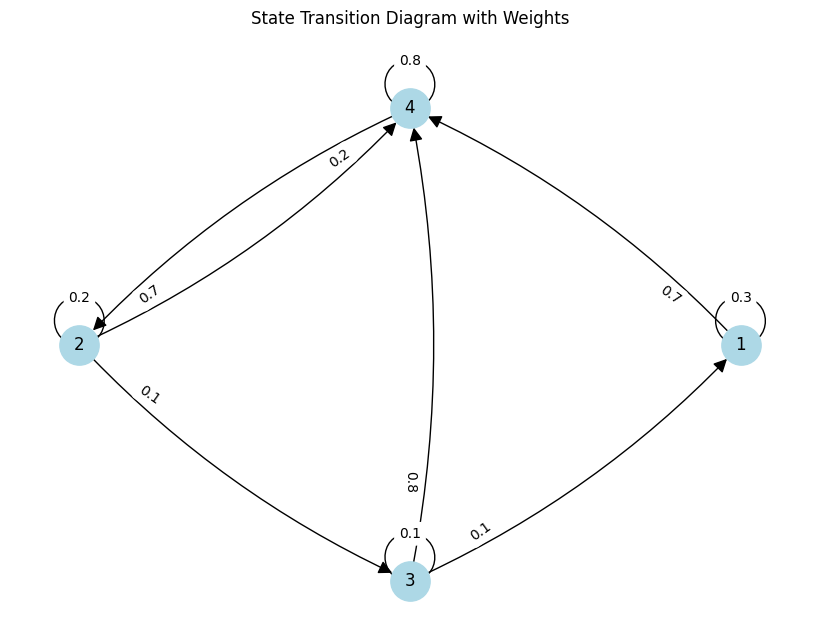

In [41]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Recordamos de la sección 4 que la distribución estacionaria de esta MC parecía estar entorno a
$$[0.003, \; 0.195, \; 0.022, \; 0.780]$$
puesto que la marginal se estabilizaba en esos valores. Veamos que, tal y como garantiza el teorema ergódico, las cantidades $q_i(n)$ convergen a la distribución estacionaria, es decir, $q_i(n) \to (\pi)_i$ cuando $n\to\infty$.

En la siguiente celda se representa la evolución de cada una de las $q_i(n)$ cuando $n$ crece (desde $1$ hasta $10000$). Al final del todo también se imprimen por pantalla los valores de $q_i(10000)$, para poder compararlos con la distribución estacionaria.

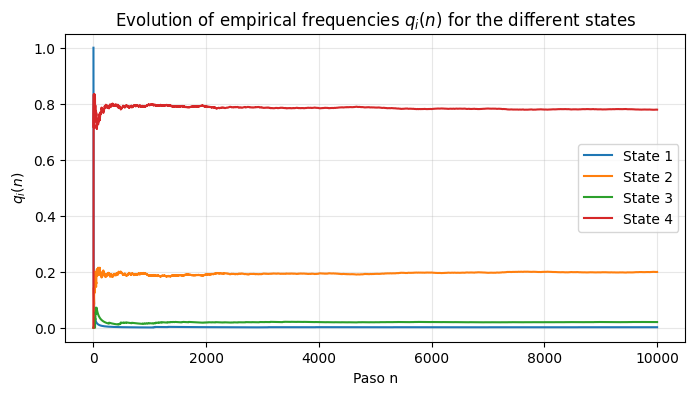

[0.0018 0.1992 0.0202 0.7788]


In [42]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1) # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i,:], label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Vemos que los valores resultantes son casi iguales a los de la distribución estacionaria.

Por último, vamos a considerar la MC periódica que vimos en la sección 4:

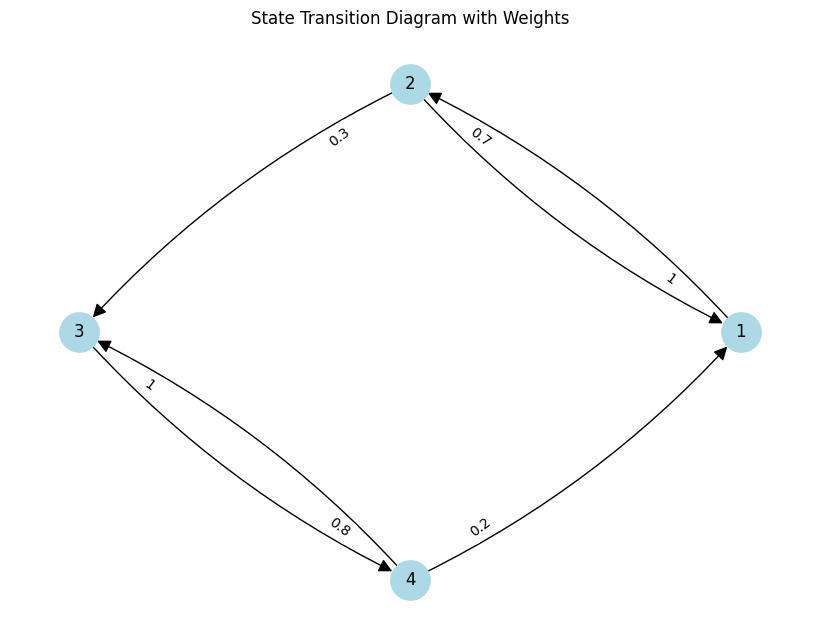

In [44]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

Vamos a seleccionar una distribución inicial ```pi_sup_1``` para la que sabemos que la distribución marginal no converge, como se vio en la sección 4. Y vamos a ver que, aunque la distribución marginal no converge, sí que se cumple el teorema ergódico, y las frecuencias a lo largo de una trayectoria sí que convergen a la distribución estacionaria. En efecto, recuerda que el teorema ergódico no requiere "aperiodicidad" (a diferencia del teorema de convergencia de MCs).

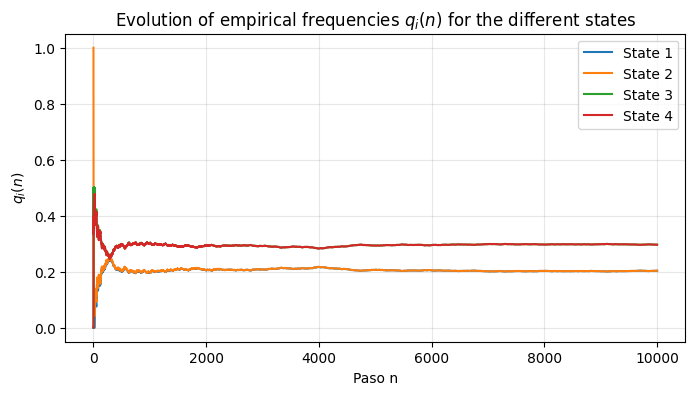

[0.2035 0.2035 0.2965 0.2965]


In [47]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1) # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i,:], label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Esto converge al valor esperado. En efecto, recuerda de la sección 4 que la única distribución estacionaria de esta MC venía dada por: [0.2, 0.2, 0.3, 0.3].